### Correlation Analysis

#### Corrections Applied:
- Fixed data alignment: Now filters news data by stock symbol before merging to ensure relevance.
- Added sentiment analysis using TextBlob on headlines.
- Aggregated daily average sentiment scores per stock.
- Computed daily stock returns (percentage change in Close price).
- Updated correlation analysis to include sentiment and returns.
- Added per-stock correlation calculations.
- References: TextBlob for sentiment (https://textblob.readthedocs.io/en/dev/), Pandas for data manipulation.

#### Data Preparation and Processing

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from textblob import TextBlob
import numpy as np

key_stocks = ['AAPL', 'NVDA', 'MSFT', 'GOOG', 'AMZN', 'META'] 

# Load the news data
news_data = pd.read_csv('../data/raw_analyst_ratings.csv')

# Convert the 'date' column to datetime with timezone UTC
news_data['date'] = pd.to_datetime(news_data['date'], format='%Y-%m-%d %H:%M:%S', errors='coerce', utc=True)

# Initialize a list to store the aligned data for each stock
aligned_dfs = []

# Loop through each stock
for stock_symbol in key_stocks:
    # Load the stock data
    stock_file = stock_symbol + ".csv"  # Assuming filename is {symbol}.csv
    stock_data = pd.read_csv("../data/" + stock_file)
    
    # Convert the 'Date' column to datetime with timezone UTC
    stock_data['Date'] = pd.to_datetime(stock_data['Date']).dt.tz_localize('UTC')
    
    # Filter news data for this specific stock
    stock_news = news_data[news_data['stock'] == stock_symbol].copy()
    
    if len(stock_news) == 0:
        print(f"No news data for {stock_symbol}")
        continue
    
    # Perform sentiment analysis on headlines
    stock_news['sentiment'] = stock_news['headline'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    
    # Aggregate daily average sentiment
    daily_sentiment = stock_news.groupby('date').agg({'sentiment': 'mean'}).reset_index()
    daily_sentiment.rename(columns={'date': 'Date'}, inplace=True)
    
    # Filter stock data to start from the first date in the stock's news data
    start_date = daily_sentiment['Date'].min()
    filtered_stock_data = stock_data[stock_data['Date'] >= start_date]
    
    # Perform an inner join to keep only matching dates
    aligned_data = pd.merge(filtered_stock_data, daily_sentiment, left_on='Date', right_on='Date', how='inner')
    
    # Calculate daily returns
    aligned_data['Return'] = aligned_data['Close'].pct_change()
    
    # Add a column to identify the stock
    aligned_data['Stock'] = stock_symbol
    
    # Append the aligned data to the list
    aligned_dfs.append(aligned_data)

# Concatenate all aligned data into one DataFrame
final_data = pd.concat(aligned_dfs, ignore_index=True)

# Drop rows with NaN returns if needed, but keep for now
final_data = final_data.dropna(subset=['Return'])

No news data for MSFT
No news data for META


In [2]:
# Ensure missing values
print(final_data.isnull().sum())

Date         0
Close        0
High         0
Low          0
Open         0
Volume       0
sentiment    0
Return       0
Stock        0
dtype: int64


In [3]:
# Check the date range 
print(f"Date range in final data: {final_data['Date'].min()} to {final_data['Date'].max()}")

Date range in final data: 2011-03-07 00:00:00+00:00 to 2020-06-02 00:00:00+00:00


In [4]:
# Check for duplicate data
print(f"Number of duplicate rows: {final_data.duplicated().sum()}")

Number of duplicate rows: 0


In [5]:
# Print sample data
print(final_data.head())
print(final_data.info())

                       Date      Close       High        Low       Open  \
1 2020-03-10 00:00:00+00:00  69.010056  69.276094  65.147678  67.026873   
2 2020-03-11 00:00:00+00:00  66.613319  68.013645  65.749906  67.087355   
3 2020-03-12 00:00:00+00:00  60.034924  65.300043  59.979299  61.899604   
4 2020-03-13 00:00:00+00:00  67.227592  67.699207  61.176455  64.064172   
5 2020-03-16 00:00:00+00:00  58.578964  62.659002  58.044470  58.516080   

      Volume  sentiment    Return Stock  
1  285290000   0.021708  0.072022  AAPL  
2  255598800   0.018624 -0.034730  AAPL  
3  418474000  -0.083048 -0.098755  AAPL  
4  370732000   0.069215  0.119808  AAPL  
5  322423600   0.011136 -0.128647  AAPL  
<class 'pandas.core.frame.DataFrame'>
Index: 1549 entries, 1 to 1552
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   Date       1549 non-null   datetime64[ns, UTC]
 1   Close      1549 non-null   float64 

#### Correlation Analysis

In [6]:
# Compute correlations per stock between sentiment and returns
correlations = {}
for stock in key_stocks:
    stock_df = final_data[final_data['Stock'] == stock]
    if len(stock_df) > 1:
        corr = stock_df[['sentiment', 'Return']].corr().iloc[0, 1]
        correlations[stock] = corr

print("Per-stock correlations between average daily sentiment and returns:")
for stock, corr in correlations.items():
    print(f"{stock}: {corr:.4f}")

# Overall correlation
overall_corr = final_data[['sentiment', 'Return']].corr().iloc[0, 1]
print(f"\nOverall correlation: {overall_corr:.4f}")

Per-stock correlations between average daily sentiment and returns:
AAPL: 0.0915
NVDA: 0.0838
GOOG: 0.0696
AMZN: -0.0448

Overall correlation: 0.0828


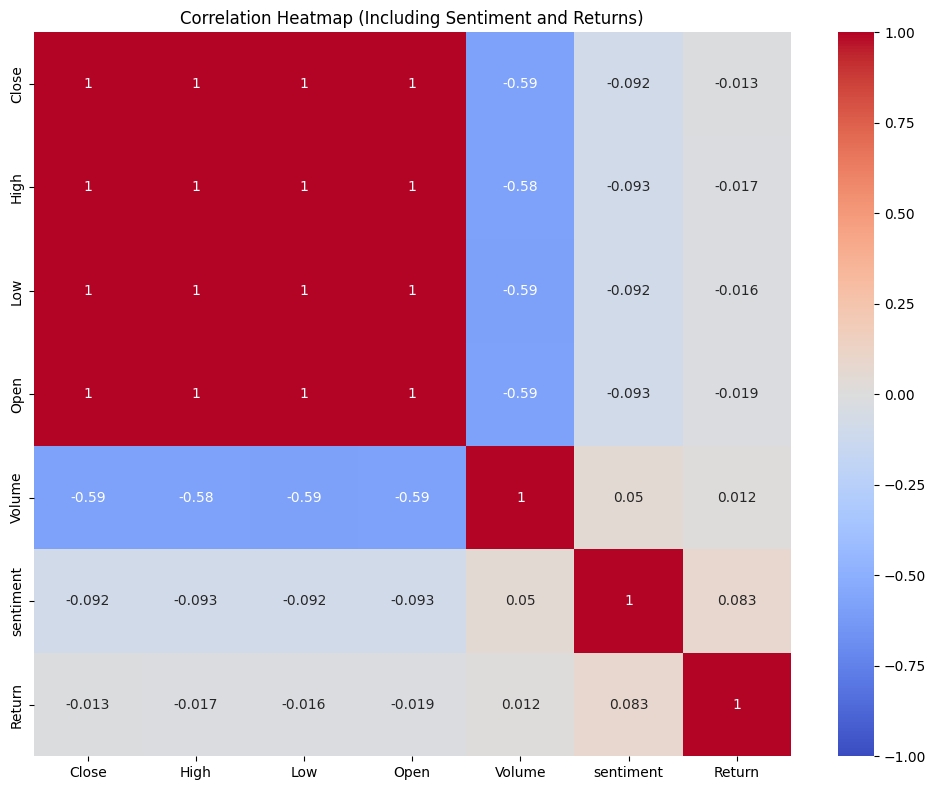

In [7]:
# Prepare numeric data for heatmap (including sentiment and Return)
numeric_data = final_data.select_dtypes(include=[np.number])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap (Including Sentiment and Returns)')
plt.tight_layout()
plt.show()